### NAME: Se Rang Seo
### Title: Assignment 9 Linear Regression
### Course: Phys255 Machine Learning
### Instructor: Professor Romanowsky

### Instructions
Find a scientific data-set suitable for regression analysis.  For example, you could include "regression" in a keyword search in <a href="https://www.kaggle.com/datasets/ignaciovinuales/battery-remaining-useful-life-rul" target="_blank">Kaggle</a> to an external site..  Try to have more than one predictor X.
Examine your data, discussing the statistics of the predictors.  Visualize with relevant plots. 
Select and apply a regression method, and visualize your fit.  
Use cross-validation and hyperparameter grid search to optimize bias and variance.  Also employ a learning curve.
Repeat with as many varieties of regression as are relevant, including regularization.
Discuss the relative performance, strengths, and weaknesses of the different methods, in the context of the scientific goals.
Upload your data-file, Jupyter Notebook, and answers to these questions (which can be in either the Notebook or a separate document).

### Battery Remaining Useful Life (RUL)
The Hawaii Natural Energy Institute examined 14 NMC-LCO 18650 batteries with a nominal capacity of 2.8 Ah, which were cycled over 1000 times at 25°C with a CC-CV charge rate of C/2 rate and discharge rate of 1.5C.

From that source dataset, I created features that showcase the voltage and current behaviour over each cycle. Those features can be used to predict the remaining useful life (RUL) of the batteries. The dataset contains the summary of the 14 batteries.

### Imports

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import (train_test_split, cross_val_score, cross_val_predict, cross_validate, cross_val_predict,
KFold, StratifiedKFold, GridSearchCV, LearningCurveDisplay, ShuffleSplit)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from astroML.linear_model import PolynomialRegression, BasisFunctionRegression, NadarayaWatson
import sklearn.gaussian_process as gp
from sklearn.model_selection import learning_curve

In [12]:
data = pd.read_csv("Battery_RUL.csv")

data

,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
0,1.0,2595.30,1151.488500,3.670,3.211,5460.001,6755.01,10777.82,1112
1,2.0,7408.64,1172.512500,4.246,3.220,5508.992,6762.02,10500.35,1111
2,3.0,7393.76,1112.992000,4.249,3.224,5508.993,6762.02,10420.38,1110
3,4.0,7385.50,1080.320667,4.250,3.225,5502.016,6762.02,10322.81,1109
4,6.0,65022.75,29813.487000,4.290,3.398,5480.992,53213.54,56699.65,1107
...,...,...,...,...,...,...,...,...,...
15059,1108.0,770.44,179.523810,3.773,3.742,922.775,1412.38,6678.88,4
15060,1109.0,771.12,179.523810,3.773,3.744,915.512,1412.31,6670.38,3
15061,1110.0,769.12,179.357143,3.773,3.742,915.513,1412.31,6637.12,2
15062,1111.0,773.88,162.374667,3.763,3.839,539.375,1148.00,7660.62,1


In [13]:
"""# Assuming 'targets' is your target column name, it should be a string

target_column = 'RUL'  # Replace with your actual target column name
cols = []

for i in range(0,len(data.columns)):
      cols.append(data.columns[i])

fig3 = plt.figure()
p = sns.pairplot(data, 
                 vars=cols,
                 corner=True, 
                 hue=target_column,  # This should be a string, not a Series
                 plot_kws={"s": 15, "alpha": 0.7})""";

In [14]:
X = data.drop('RUL', axis=1)  # All columns except target

y = data['RUL']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.4, random_state=42)

# Linear Regression

In [15]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

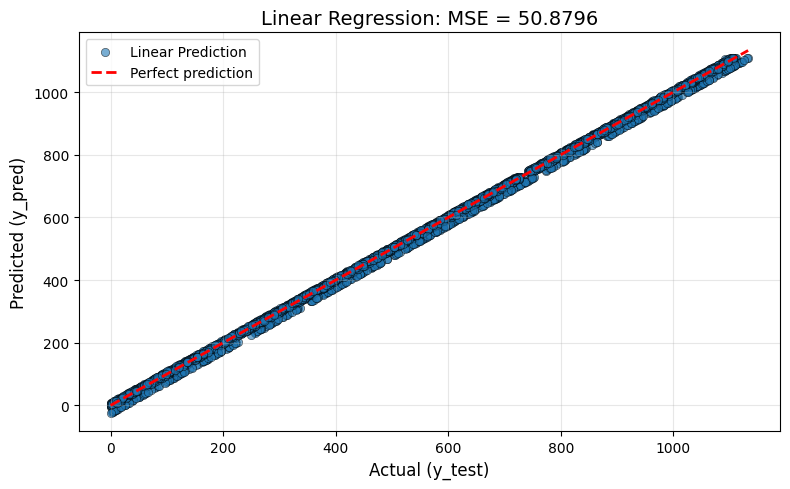

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', linewidth=0.5, label = "Linear Prediction")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual (y_test)', fontsize=12)
plt.ylabel('Predicted (y_pred)', fontsize=12)
plt.title(f'Linear Regression: MSE = {mean_squared_error(y_test, y_pred):.4f}', 
          fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


units = cycles

<Figure size 640x480 with 0 Axes>

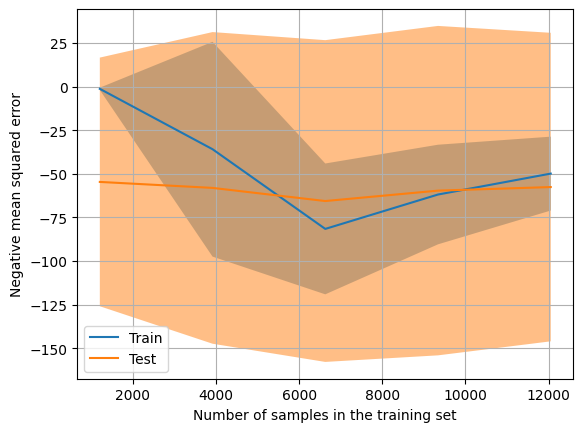

In [17]:
fig = plt.figure();
LearningCurveDisplay.from_estimator(model,X,y,cv=5,scoring='neg_mean_squared_error');
plt.grid();

This shows that the algorithm is underfit because of how far off the lines are from 0.

My train is horizontal, meaning it's not learning anything.

This is the same result as the linear since the best degree is 1.
AI is telling me this is underfitting and I need more complex algorithms.

# Polynomial Regression

Testing degree 5

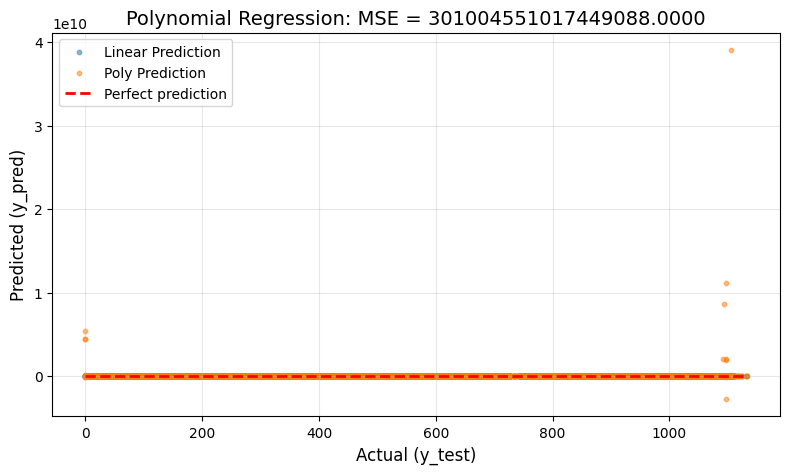

<Figure size 640x480 with 0 Axes>

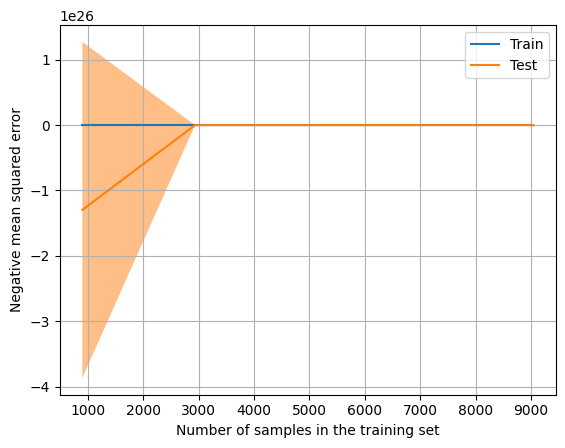

In [18]:
# Train model
model_poly = PolynomialRegression(5)
model_poly.fit(X_train, y_train)
y_pred_poly = model_poly.predict(X_test)

# Plot Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, s=10,label = "Linear Prediction")
plt.scatter(y_test, y_pred_poly, alpha=0.5,s=10, label = "Poly Prediction")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual (y_test)', fontsize=12)
plt.ylabel('Predicted (y_pred)', fontsize=12)
plt.title(f'Polynomial Regression: MSE = {mean_squared_error(y_test, y_pred_poly):.4f}', 
          fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Learning curve
fig_poly = plt.figure()
LearningCurveDisplay.from_estimator(model_poly,X,y,cv=ShuffleSplit(n_splits=6, test_size=0.4, random_state=42),scoring='neg_mean_squared_error')
plt.grid()

When the degree gets high, it gets messy.

### Using GridSearch and Pipeline on Polynomial Regression

Best degree: 1


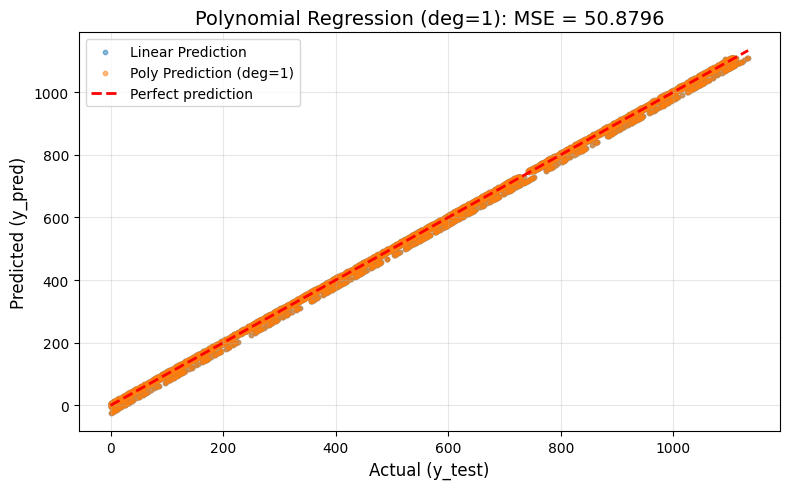

<Figure size 640x480 with 0 Axes>

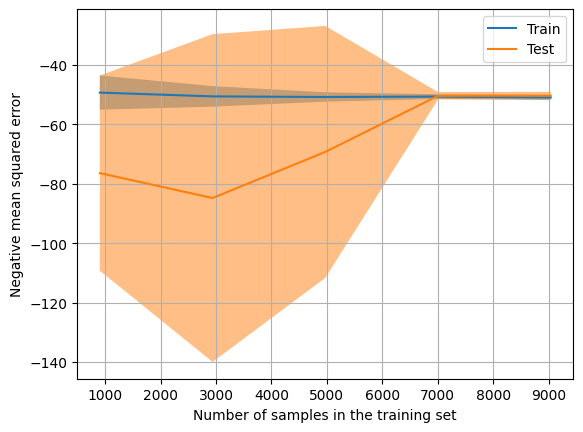

In [19]:
# Find best degree with GridSearchCV
pipeline_poly = make_pipeline(PolynomialFeatures(), LinearRegression())
param_grid = {'polynomialfeatures__degree': [1, 2, 3, 4]}
grid_search = GridSearchCV(pipeline_poly, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

best_degree = grid_search.best_params_['polynomialfeatures__degree']
print(f"Best degree: {best_degree}")

# Train model with best degree
model_poly = PolynomialRegression(best_degree)
model_poly.fit(X_train, y_train)
y_pred_poly = model_poly.predict(X_test)

# Plot Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, s=10, label="Linear Prediction")
plt.scatter(y_test, y_pred_poly, alpha=0.5, s=10, label=f"Poly Prediction (deg={best_degree})")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual (y_test)', fontsize=12)
plt.ylabel('Predicted (y_pred)', fontsize=12)
plt.title(f'Polynomial Regression (deg={best_degree}): MSE = {mean_squared_error(y_test, y_pred_poly):.4f}', 
          fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Learning curve
fig_poly = plt.figure()
LearningCurveDisplay.from_estimator(model_poly, X, y, 
                                     cv=ShuffleSplit(n_splits=6, test_size=0.4, random_state=42),
                                     scoring='neg_mean_squared_error')
plt.grid()
plt.show()

The best fit ends up being just linear regression or polynomial with degree 1.

# Gaussian Process

Fitting 2 folds for each of 4 candidates, totalling 8 fits
Best alpha for GP: 0.1
GP MSE: 3003.2541


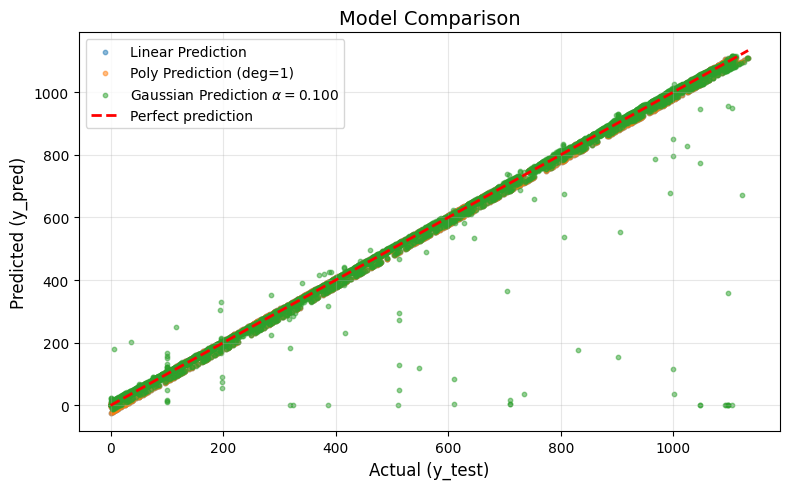

<Figure size 640x480 with 0 Axes>

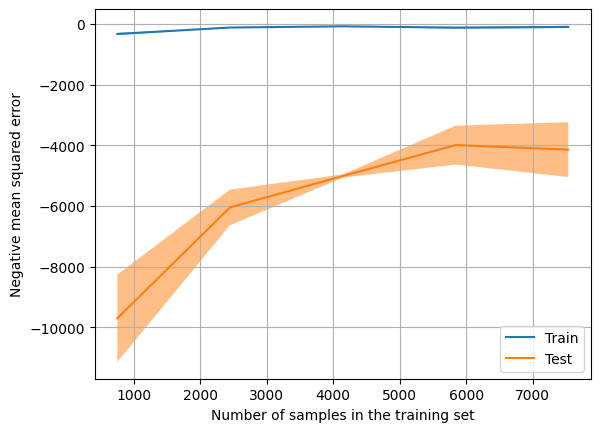

In [20]:
# GridSearchCV for Gaussian Process
kernel1 = gp.kernels.RBF(length_scale = 1)
param_grid = {
    'alpha': [0.01, .1, 10, 100],  # Regularization parameter
}

grid_search_gp = GridSearchCV(
    gp.GaussianProcessRegressor(kernel=kernel1),
    param_grid, 
    cv=2,  # Reduce from 3 to 2 folds
    scoring='neg_mean_squared_error',
    n_jobs=-1,  # Parallel processing
    verbose=1
)

grid_search_gp.fit(X_train, y_train)

best_alpha = grid_search_gp.best_params_['alpha']
print(f"Best alpha for GP: {best_alpha}")

# Train GP model with best alpha
model_gp = gp.GaussianProcessRegressor(kernel=kernel1, alpha=best_alpha)
model_gp.fit(X_train, y_train)
y_pred_gp = model_gp.predict(X_test)

print(f"GP MSE: {mean_squared_error(y_test, y_pred_gp):.4f}")


# Plot Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, s=10, label="Linear Prediction")
plt.scatter(y_test, y_pred_poly, alpha=0.5, s=10, label=f"Poly Prediction (deg={best_degree})")
plt.scatter(y_test, y_pred_gp, alpha=0.5, s=10, label = f"Gaussian Prediction $\\alpha={best_alpha:.3f}$")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual (y_test)', fontsize=12)
plt.ylabel('Predicted (y_pred)', fontsize=12)
plt.title('Model Comparison', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Optimized learning curve
fig_gp = plt.figure()
LearningCurveDisplay.from_estimator(
    model_gp, X, y, 
    cv=2,  # Minimal CV
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
plt.grid()
plt.show()

The algorithm is not learning since the train is set to 0. So, there is a huge covariance since theres a big gap between 0 and the test. I'm only using 30% of the training data because it takes so long to run, so there is overfitting.

Overall, I'd prob need more time to try different algorithms. My gaussian algorithm isnt learning anything because the learning curve training is fixed at 0. And, since my best fit for polynomial regression was degree 1, it was repetition of linear regression.